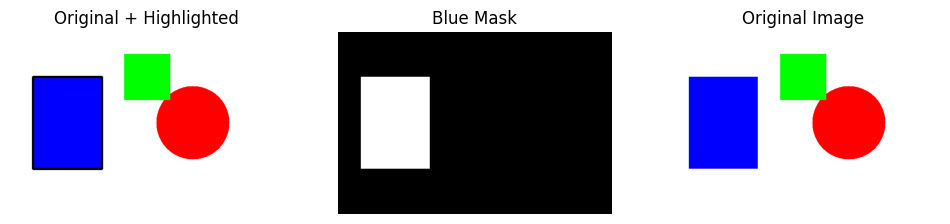

In [1]:
# ============================================
# Color Detection and Object Highlighting
# Beginner Friendly
# Ready for Google Colab
# ============================================

# Install OpenCV (first time only)
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Step 1: Create a Sample Image
# -----------------------------------------

# Create white image
image = np.ones((400, 600, 3), dtype=np.uint8) * 255

# Draw colored objects
cv2.rectangle(image, (50, 100), (200, 300), (255, 0, 0), -1)   # Blue rectangle
cv2.circle(image, (400, 200), 80, (0, 0, 255), -1)             # Red circle
cv2.rectangle(image, (250, 50), (350, 150), (0, 255, 0), -1)   # Green square

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# -----------------------------------------
# Step 2: Convert Image to HSV Color Space
# -----------------------------------------

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# -----------------------------------------
# Step 3: Define Blue Color Range
# -----------------------------------------

# HSV range for blue color
lower_blue = np.array([100, 100, 100])
upper_blue = np.array([140, 255, 255])

# Create mask
mask = cv2.inRange(hsv, lower_blue, upper_blue)

# -----------------------------------------
# Step 4: Find Contours (Objects)
# -----------------------------------------

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw bounding boxes around detected objects
for contour in contours:
    if cv2.contourArea(contour) > 500:  # ignore small noise
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (0, 0, 0), 3)

# -----------------------------------------
# Step 5: Display Results
# -----------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original + Highlighted")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Blue Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.show()